# ICL Sample Viewer — exactly what the model sees\nPicks a random dataset with a description, builds one ICL prompt via the runtime pipeline, and renders each `<ts><ts/>` placeholder as the exact matplotlib image the VL model receives.

In [1]:
import sys, random, io
sys.path.insert(0, '/home/aviramom/projects/multimodalTS')

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML
import ipywidgets as widgets
from types import SimpleNamespace

from data_provider.dataset_ucr import UCRDataset
from data_provider.dataset import MultiTSDataset

# ── config ────────────────────────────────────────────────────────────────────
DATA_PATH   = '/cs/azencot_fsas/multimodal_ts/datasets/Univariate_arff'
DESC_PATH   = '/home/aviramom/projects/multimodalTS/ucr_descriptions'
SEED        = 42
K_SHOTS     = 1          # shots per class (matches experiment default)
SAMPLE_IDX  = 0          # which test sample to display

DATASETS_WITH_DESC = [
    'AllGestureWiimoteX','AllGestureWiimoteY','AllGestureWiimoteZ',
    'BME','Chinatown','Crop','DodgersLoopDay','DodgersLoopGame',
    'DodgersLoopWeekend','EthanolLevel','Fungi','GunPointAgeSpan',
    'GunPointMaleVersusFemale','GunPointOldVersusYoung','Lightning7',
    'MelbournePedestrian','MixedShapesRegularTrain','MixedShapesSmallTrain',
    'PickupGestureWiimoteZ','PowerCons','Rock','SemgHandGenderCh2',
    'SemgHandMovementCh2','SemgHandSubjectCh2','ShakeGestureWiimoteZ',
    'SmoothSubspace','SwedishLeaf','SyntheticControl','TwoPatterns','UMD',
]

random.seed(SEED)
DATASET_NAME = random.choice(DATASETS_WITH_DESC)
print(f"Selected dataset: {DATASET_NAME}")

/home/aviramom/.conda/envs/multits/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/home/aviramom/.conda/envs/multits/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


anthropic not installed.
Selected dataset: Rock


In [2]:
# ── Build the ICL sample via the runtime pipeline ─────────────────────────────
ucr_path  = f'{DATA_PATH}/{DATASET_NAME}'
train_ds  = UCRDataset(ucr_path, split='train')
test_ds   = UCRDataset(ucr_path, split='test')

args = SimpleNamespace(
    picking_strategy='random',
    num_shots=K_SHOTS,
    random_seed=SEED,
    use_label_desc=1,       # inject description.txt into prompt
)

multits = MultiTSDataset(input_mode='separate')   # keeps <ts><ts/> tokens
multits.from_icl_ucr_dataset({'train': train_ds, 'test': test_ds},
                              task_id=f'ICL_UCR_{DATASET_NAME}', args=args)

sample    = multits[SAMPLE_IDX]
prompt    = sample['input_text']
gt_label  = sample['output_text']
ts_list   = sample['input_ts']   # list of arrays: [ex1, ex2, ..., target]

print(f"Ground-truth label : {gt_label}")
print(f"Number of TS in prompt: {len(ts_list)}  (= {len(ts_list)-1} examples + 1 target)")
print(f"TS length: {len(ts_list[0])}")
print()
print("─── Raw prompt text ──────────────────────────────────")
print(prompt)

Ground-truth label : 1
Number of TS in prompt: 5  (= 4 examples + 1 target)
TS length: 2844

─── Raw prompt text ──────────────────────────────────
Time Series Classification.
The data contain 70 rock examples from the ASTER spectral library [1]. Each series is rock spectral reflectance as a function of wavelength in micron, not time.

Classes correspond to type of rocks.

- Class 1: marfic 
- Class 2: quartzite
- Class 3: marble 
- Class 4: schist

--- EXAMPLES ---

Example 1 Time Series: <ts><ts/>
Label: 1

Example 2 Time Series: <ts><ts/>
Label: 2

Example 3 Time Series: <ts><ts/>
Label: 3

Example 4 Time Series: <ts><ts/>
Label: 4

--- TARGET ---
New Time Series: <ts><ts/>
Return ONLY the label as one of: [1, 2, 3, 4] without any explanation




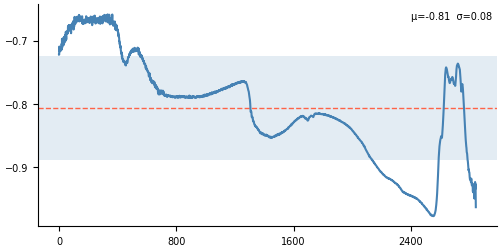
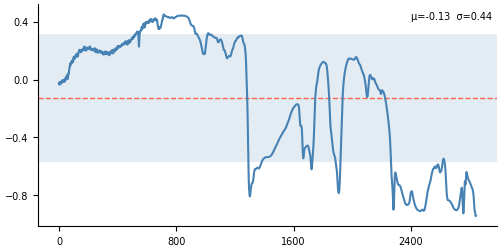
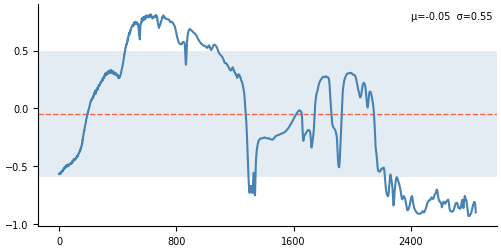
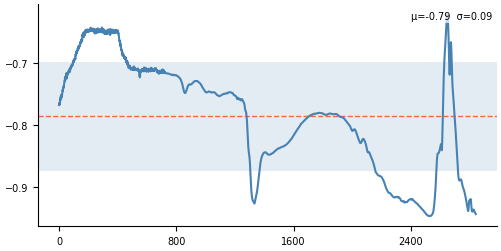
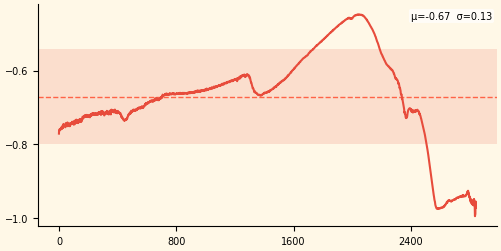

In [3]:
# ── Replicate _plot_ts_to_pil exactly as the model sees it ───────────────────
def plot_ts_to_pil(ts_values, color="steelblue", title=None, highlight=False):
    """Mirrors _plot_ts_to_pil in the model files exactly, with viewer extras (color/highlight/title)."""
    import matplotlib.ticker as ticker

    arr = np.asarray(ts_values, dtype=float).ravel()
    mask = ~np.isnan(arr)
    xs = np.where(mask)[0]
    ys = arr[mask]

    mean = float(np.mean(ys))
    std = float(np.std(ys))

    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=100)

    if highlight:
        fig.patch.set_facecolor('#fff8e7')
        ax.set_facecolor('#fff8e7')

    ax.axhspan(mean - std, mean + std, alpha=0.15, color=color, linewidth=0)
    ax.axhline(mean, color="tomato", linewidth=1.0, linestyle="--")
    ax.plot(xs, ys, linewidth=1.5, color=color)

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

    ax.annotate(
        f"μ={mean:.2f}  σ={std:.2f}",
        xy=(0.99, 0.97), xycoords="axes fraction",
        ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"),
    )

    if title:
        ax.set_title(title, fontsize=9, pad=2)

    fig.tight_layout(pad=0.3)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return buf.read()

# ── Render the full prompt as HTML, images inline ─────────────────────────────
PLACEHOLDER = "<ts><ts/>"
parts = prompt.split(PLACEHOLDER)
n_ts  = len(parts) - 1
assert n_ts == len(ts_list), f"Mismatch: {n_ts} placeholders vs {len(ts_list)} TS"

html_parts = ['<div style="font-family:monospace;font-size:13px;line-height:1.8;'
              'background:#1e1e1e;color:#d4d4d4;padding:20px;border-radius:8px;'
              'white-space:pre-wrap">']

for i, part in enumerate(parts):
    escaped = (part.replace('&','&amp;').replace('<','&lt;').replace('>','&gt;'))
    html_parts.append(escaped)

    if i < n_ts:
        is_target = (i == n_ts - 1)
        color     = '#e74c3c' if is_target else 'steelblue'
        label_str = f"TARGET  (GT={gt_label})" if is_target else f"Example {i+1}"
        img_bytes = plot_ts_to_pil(ts_list[i], color=color, highlight=is_target)
        import base64
        b64 = base64.b64encode(img_bytes).decode()
        border = '3px solid #e74c3c' if is_target else '1px solid #555'
        caption_color = '#e74c3c' if is_target else '#aaa'
        html_parts.append(
            f'<div style="display:inline-block;vertical-align:middle;margin:4px 6px;'
            f'border:{border};border-radius:4px">'
            f'<div style="text-align:center;font-size:10px;color:{caption_color};'
            f'padding:2px">{label_str}</div>'
            f'<img src="data:image/png;base64,{b64}" style="display:block"/>'
            f'</div>'
        )

html_parts.append('</div>')
display(HTML(''.join(html_parts)))